# 데이터 전처리 결과서

수집한 데이터 : Kaggle hotel booking demand dataset  
수집한 방법 : Kaggle 제공  
Feature 설명 :  
- **hotel**: 호텔 식별자 (리조트 호텔인지 시티 호텔인지)
- **is_canceled**: 예약이 취소되었는지 여부를 나타내는 값 (1: 취소, 0: 취소되지 않음)
- **lead_time**: 예약 입력 날짜와 도착 날짜 사이에 경과된 일수
- **arrival_date_year**: 도착 날짜의 연도
- **arrival_date_month**: 도착 날짜의 월
- **arrival_date_week_number**: 도착 날짜의 연도 주 번호(값이 32면 1월1일부터 7*32일 이후)
- **arrival_date_day_of_month**: 도착 날짜의 일
- **stays_in_weekend_nights**: 손님이 호텔에서 머문 주말 밤 수 (토요일 또는 일요일)
- **stays_in_week_nights**: 손님이 호텔에서 머문 주중 밤 수 (월요일부터 금요일)
- **adults**: 성인 수
- **children**: 어린이 수
- **babies**: 아기 수
- **meal**: 예약된 식사 유형
- **country**: 출신 국가  
- **market_segment**: 시장 세그먼트 지정. 카테고리에서 "TA"는 "Travel Agents"를 의미하고 "TO"는 "Tour Operators"를 의미
- **distribution_channel**: 예약 배포 채널. "TA"는 "Travel Agents"를 의미하고 "TO"는 "Tour Operators"를 의미
- **is_repeated_guest**: 예약자가 반복 손님인지 여부를 나타내는 값 (1: 반복, 0: 비반복)
- **previous_cancellations**: 현재 예약 이전에 고객이 취소한 이전 예약 수
- **previous_bookings_not_canceled**: 현재 예약 이전에 고객이 취소하지 않은 이전 예약 수
- **reserved_room_type**: 예약된 객실 유형 코드. 익명성을 위해 지정 대신 코드로 제시
- **assigned_room_type**: 예약에 할당된 객실 유형 코드  
- **booking_changes**: 예약이 PMS에 입력된 순간부터 체크인 또는 취소 순간까지 예약에 대한 변경/수정 수
- **deposit_type**: 고객이 예약을 보장하기 위해 보증금을 납부했는지 여부 표시. No Deposit, Non Refund, Refundable  
- **agent**: 예약을 한 여행사의 ID
- **company**: 예약을 한 회사/단체의 ID 또는 예약 비용을 지불하는 책임자. 익명성을 위해 지정 대신 ID로 제시
- **days_in_waiting_list**: 예약이 고객에게 확인되기 전에 대기 목록에 있었던 일수
- **customer_type**: 예약 유형, 네 가지 카테고리 중 하나: Contract, Group, Transient, Transient-party  
- **adr**: 모든 숙박 거래의 합계를 총 숙박 밤 수로 나누어 정의된 평균 일일 요금
- **required_car_parking_spaces**: 고객이 요구하는 주차 공간 수
- **total_of_special_requests**: 고객이 한 특별 요청 수
- **reservation_status**: 예약 마지막 상태, 세 가지 카테고리 중 하나: Canceled, Check-Out, No-Show
- **reservation_status_date**: 마지막 상태가 설정된 날짜. ReservationStatus와 함께 사용하여 예약이 언제 취소되었거나 고객이 호텔에서 체크아웃했는지 이해할 수 있음

# EDA 수행 결과

우선 단순 명세를 통해 reservation status는 is_canceled와 함께 예약을 취소했는지  
안했는지에 대한 target value가 됨을 알 수 있었음. target value는 is_canceled 하나만 있으면 되기에 reservation_status를 drop  
  
reservation_status_date 컬럼 또한 이 값을 arrival_date와 관련된 정보와의 선후행을 통해 이 사람이 cancel했는지 checkout을 했는지 예측이 가능해져 leakage가 발생할 수 있기 때문에 drop  
  
  
## 결측치 시각화
company, agent, country, children에만 결측치가 존재  

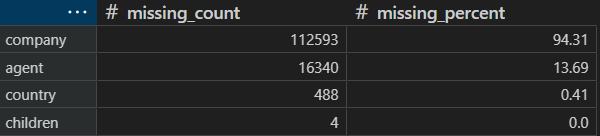
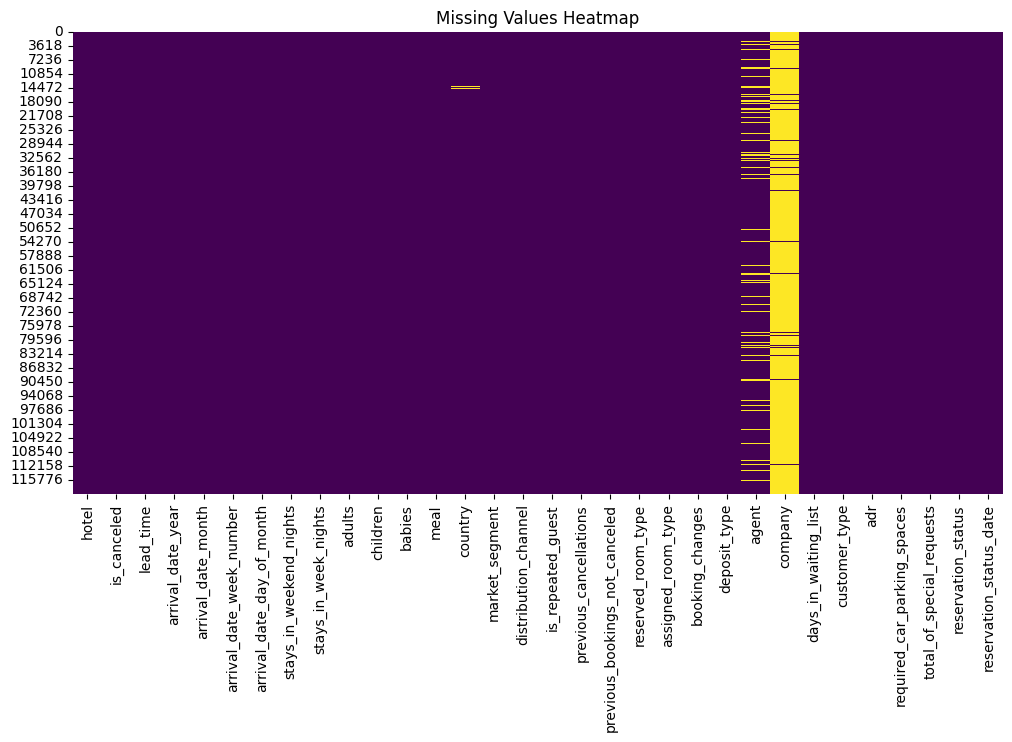
  
country 일부, company와 agent에 결측치가 다수 존재함을 확인  
company는 대부분이 결측치이기 때문에 피처 자체를 drop  
agent는 범주형 피처이므로 최빈값으로 대체하여 일반성 유지  


## 이상치 탐지  

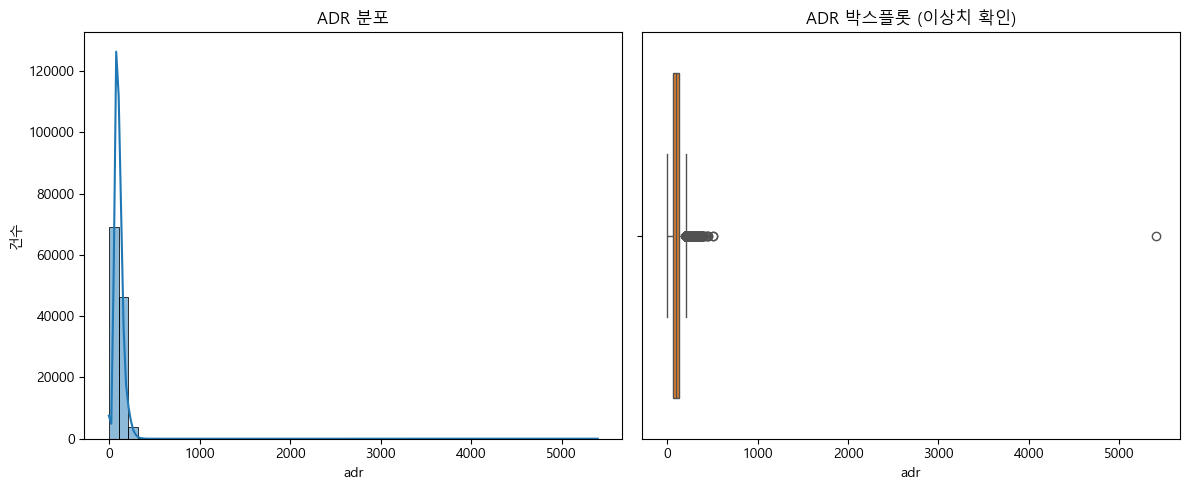  
adr에 이상치 값 존재 확인. 99%의 분포가 0~5000사이에 분포하므로 그 이상 row는 제거  


## 라벨 불균형  

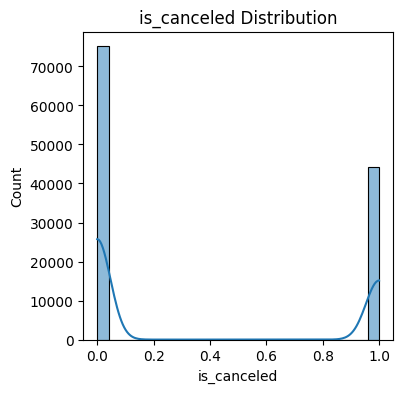  
  
label 불균형이 심하진 않지만 존재함을 확인. => scale_pos_weight을 통해 클래스별로 가중치를 다르게 학습하여 불균형 해결  

## 

